In [1]:
# Poisson Distribution (PMF)

# Belirli bir zaman aralıgında ya da sabit bir alanda bir olay kaç kez gerçekleşeceğini modelleyen bir dağılım
# Bir çağrı merkezine saatte kaç çağrı gelicek
# 1 dakikada ışıklardan kaç araç geciyor
# Web sitesine saatte gelen istek sayısı
# Hastanede saatte kaç kişi doğdu

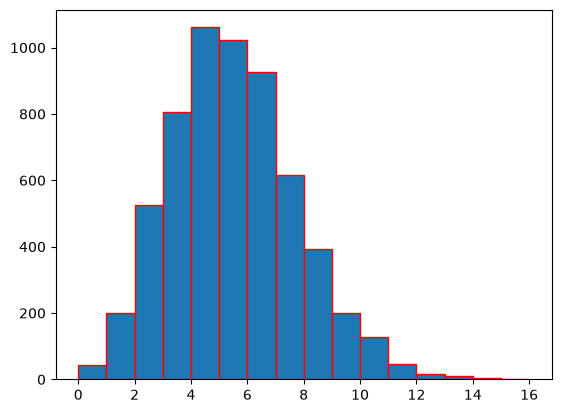

In [2]:
# Bir otoparkta saatte ortalama 5 araç giriş yapmaktadır
# Poission dağılımına göre 6000 tane araç gelmiş olsun. Bunu modelleyelim
# lambda = 5

import numpy as np
import matplotlib.pyplot as plt

lmbda = 5
size = 6000

samples = np.random.poisson(lmbda, size = 6000)
plt.hist(samples, bins = (range(0,max(samples) + 2)), edgecolor = "red")
plt.show()

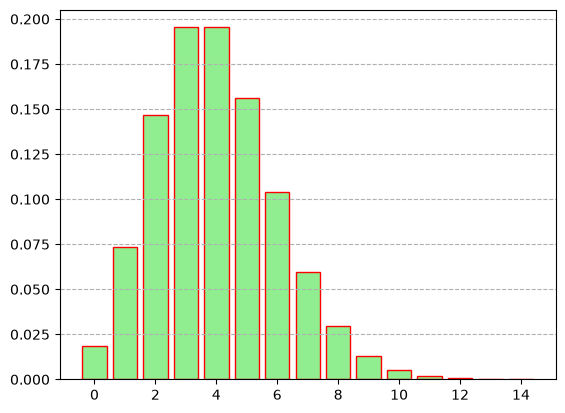

In [3]:
from scipy.stats import poisson
lmbda = 4

distribution = poisson(mu = (lmbda))
x = np.arange(0,15)
y = distribution.pmf(x)

plt.bar(x,y,color = "lightgreen", edgecolor = "red")
plt.grid(axis = "y", linestyle = "--")
plt.show()

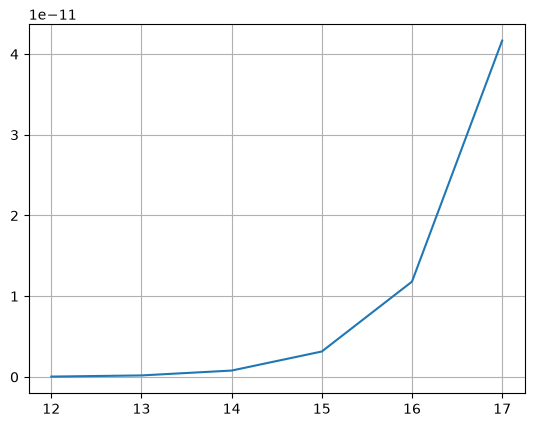

In [4]:
# Çağrı merkezinde saatte 60 tane çağrı geliyor
# Saat 12'den 17ê kadar çağrı dağılımı nasıl olur
# poisson = (e* lambda * lambda * x) / x!
# P(X = 12)

import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt


lmbda = 60
distribution = poisson(mu = (lmbda))
x = np.arange(12,18)

y = distribution.pmf(x)

plt.plot(x, y)
plt.grid(True)
plt.show()

---
# 📚 POISSON DAĞILIMI (POISSON DISTRIBUTION) - DETAYLI TEORİ VE UYGULAMA REHBERİ
### Olasılık Dağılımları Serisi - 03

---

## 📌 1. Giriş ve Sezgisel Anlatım

**Poisson Dağılımı**, belirli ve sabit bir zaman aralığında, alanda, hacimde veya uzunlukta meydana gelen olayların sayısını modelleyen **ayrık (discrete) bir olasılık dağılımıdır**.

Fransız matematikçi **Siméon Denis Poisson (1781–1840)** tarafından 1837 yılında geliştirilmiştir.

### 🔍 Bir Sürecin Poisson Dağılımına Uyması İçin 3 Temel Koşul:
1. **Bağımsızlık (Independence):** Bir zaman aralığında meydana gelen olay sayısı, diğer ayrık zaman aralıklarında meydana gelen olay sayısından bağımsızdır.
2. **Sabit Oran (Constant Rate - $\lambda$):** Birim zaman/alan başına ortalama gerçekleşme oranı ($\lambda$) süreç boyunca sabit kalmalıdır.
3. **Eşzamanlılık Olamaması (Non-Simultaneity):** Yeterince küçük bir zaman aralığında ($\Delta t \to 0$), aynı anda iki veya daha fazla olayın gerçekleşme olasılığı sıfıra yaklaşır.

### 🌍 Günlük Hayattan Örnekler:
- 📞 **Çağrı Merkezi:** 1 saatte müşteri hizmetlerine gelen çağrı sayısı.
- 🚦 **Trafik Akışı:** Belirli bir kavşaktan dakikada geçen araç sayısı.
- 🌐 **Sunucu Trafiği (Web Requests):** Bir web sunucusuna saniyede gelen HTTP istek sayısı.
- 🏥 **Sağlık & Tıp:** Bir hastanenin acil servisine gece saatlerinde gelen hasta sayısı.
- 🖨️ **Baskı & Üretim:** Bir kumaş topunda metre başına düşen dokuma hatası sayısı.

---
## 📐 2. Matematiksel Tanım ve Olasılık Kütle Fonksiyonu (PMF)

Bir rastgele değişken $X$, ortalama $\lambda$ (lambda) gerçekleşme hızı ile Poisson dağılımına sahipse şu şekilde gösterilir:

$$X \sim \text{Poisson}(\lambda)$$

Burada:
- $\lambda > 0$: Birim zaman/alan başına beklenen ortalama olay sayısı (Oran parametresi / Rate parameter)
- $k \in \{0, 1, 2, 3, \dots\}$: İncelenen zaman diliminde gerçekleşen olay sayısı ($k \in \mathbb{N}_0$)
- $e \approx 2.71828$: Euler sayısı (Doğal logaritma tabanı)

### 🔹 Olasılık Kütle Fonksiyonu (Probability Mass Function - PMF)
Belirli bir aralıkta tam olarak $k$ adet olayın gerçekleşme olasılığı:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

### 🔹 Kümülatif Dağılım Fonksiyonu (Cumulative Distribution Function - CDF)
Belirli bir aralıkta en fazla $k$ adet olayın gerçekleşme olasılığı:

$$F(k) = P(X \le k) = \sum_{i=0}^k \frac{\lambda^i e^{-\lambda}}{i!}$$

---

## 📊 3. İstatistiksel Özellikler ve Eşitlik İlkesi (Equidisperson)

> 💡 **Poisson Dağılımının En Önemli Özelliği:** Beklenen Değeri ile Varyansı birbirine tam olarak eşittir ($E[X] = \text{Var}(X) = \lambda$).

| İstatistiksel Metrik | Formül | Açıklama |
| :--- | :--- | :--- |
| **Beklenen Değer (Mean / $E[X]$)** | $\mu = \lambda$ | Birim aralıkta ortalama gerçekleşme sayısıdır. |
| **Varyans (Variance / $\text{Var}(X)$)** | $\sigma^2 = \lambda$ | Dağılımdaki değişkenlik ortalamaya eşittir. |
| **Standart Sapma (Standard Deviation)** | $\sigma = \sqrt{\lambda}$ | Varyansın kareköküdür. |
| **Çarpıklık (Skewness / $\gamma_1$)** | $\gamma_1 = \frac{1}{\sqrt{\lambda}}$ | $\lambda$ büyüdükçe $\gamma_1 \to 0$ olur ve dağılım simetrikleşir. |
| **Basıklık (Kurtosis Excess)** | $\text{Kurt} = \frac{1}{\lambda}$ | $\lambda$ büyüdükçe Normal dağılım basıklığına yaklaşır. |
| **Mod (Mode)** | $\lfloor \lambda \rfloor$ | En yüksek olasılığa sahip olay sayısıdır. |

---
## 💻 4. Python ile Kütüphaneleri Yükleme ve Ortam Ayarları

In [5]:
# Gerekli kütüphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, binom
from IPython.display import display

# Grafik estetiği ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Rastgelelik tohumu
np.random.seed(42)

print("✅ Poisson Dağılımı analiz ortamı hazırlandı!")

✅ Poisson Dağılımı analiz ortamı hazırlandı!


---
## 🎯 5. Gerçek Hayat Problemleri ve Adım Adım Çözümler

Notebook'un başında ele alınan örnekleri analitik olarak çözelim:

### 🅿️ Problem 1: Otopark Araç Giriş Modeli ($\lambda = 5$ araç/saat)
Bir otoparka saatte ortalama 5 araç girmektedir. Bir saatte:
1. Tam 5 araç gelme olasılığı $P(X = 5)$
2. En fazla 3 araç gelme olasılığı $P(X \le 3)$
3. 8'den fazla araç gelme (yoğunluk) olasılığı $P(X > 8)$

In [6]:
lam1 = 5  # Saatte ortalama 5 araç

prob_exact_5 = poisson.pmf(k=5, mu=lam1)   # P(X = 5)
prob_max_3 = poisson.cdf(k=3, mu=lam1)     # P(X <= 3)
prob_more_8 = poisson.sf(k=8, mu=lam1)     # P(X > 8) = 1 - P(X <= 8)

print(f"🅿️ Otopark Modeli (lambda = {lam1} araç/saat):")
print("-" * 45)
print(f"1. Tam 5 Araç Gelme Olasılığı P(X = 5)    : %{prob_exact_5 * 100:.2f} ({prob_exact_5:.4f})")
print(f"2. En Fazla 3 Araç Gelme Olasılığı P(X <= 3): %{prob_max_3 * 100:.2f} ({prob_max_3:.4f})")
print(f"3. 8'den Fazla Araç Gelme Olasılığı P(X > 8) : %{prob_more_8 * 100:.2f} ({prob_more_8:.4f})")

🅿️ Otopark Modeli (lambda = 5 araç/saat):
---------------------------------------------
1. Tam 5 Araç Gelme Olasılığı P(X = 5)    : %17.55 (0.1755)
2. En Fazla 3 Araç Gelme Olasılığı P(X <= 3): %26.50 (0.2650)
3. 8'den Fazla Araç Gelme Olasılığı P(X > 8) : %6.81 (0.0681)


### 📞 Problem 2: Çağrı Merkezi Modeli ($\lambda = 60$ çağrı/saat)
Bir çağrı merkezine saatte ortalama 60 çağrı gelmektedir:
- **Dakika bazında oran:** $\lambda_{dakika} = \frac{60}{60} = 1$ çağrı/dakika.
- **Soru:** Herhangi bir 1 dakikalık sürede hiç çağrı gelmeme ($k=0$) ve tam 2 çağrı gelme ($k=2$) olasılıkları nedir?

In [7]:
lam_min = 60 / 60  # lambda = 1 çağrı/dakika

prob_no_call = poisson.pmf(k=0, mu=lam_min)   # P(X = 0)
prob_2_calls = poisson.pmf(k=2, mu=lam_min)   # P(X = 2)
prob_at_least_1 = poisson.sf(k=0, mu=lam_min) # P(X >= 1)

print(f"📞 Çağrı Merkezi Modeli (Dakika Başına lambda = {lam_min:.1f}):")
print("-" * 45)
print(f"1. 1 Dakikada Hiç Çağrı Gelmeme Olasılığı P(X = 0)  : %{prob_no_call * 100:.2f} ({prob_no_call:.4f})")
print(f"2. 1 Dakikada Tam 2 Çağrı Gelme Olasılığı P(X = 2)  : %{prob_2_calls * 100:.2f} ({prob_2_calls:.4f})")
print(f"3. 1 Dakikada En Az 1 Çağrı Gelme Olasılığı P(X >= 1): %{prob_at_least_1 * 100:.2f} ({prob_at_least_1:.4f})")

📞 Çağrı Merkezi Modeli (Dakika Başına lambda = 1.0):
---------------------------------------------
1. 1 Dakikada Hiç Çağrı Gelmeme Olasılığı P(X = 0)  : %36.79 (0.3679)
2. 1 Dakikada Tam 2 Çağrı Gelme Olasılığı P(X = 2)  : %18.39 (0.1839)
3. 1 Dakikada En Az 1 Çağrı Gelme Olasılığı P(X >= 1): %63.21 (0.6321)


---
## 🔬 6. SciPy ile Poisson Dağılım Fonksiyonları

`scipy.stats.poisson` sınıfının sağladığı fonksiyonlar:
- `poisson.pmf(k, mu)`: $P(X = k)$
- `poisson.cdf(k, mu)`: $P(X \le k)$
- `poisson.sf(k, mu)`: $P(X > k)$
- `poisson.ppf(q, mu)`: Ters CDF (Quantile)
- `poisson.rvs(mu, size=N)`: Rastgele Poisson verisi üretimi
- `poisson.stats(mu, moments='mvsk')`: Ortalama, varyans, çarpıklık ve basıklık hesabı

In [8]:
mu_param = 8.5
mean, var, skew, kurt = poisson.stats(mu=mu_param, moments='mvsk')

print(f"🔹 Poisson(lambda = {mu_param}) Moment Analizi:")
print("-" * 45)
print(f"📊 Ortalama (E[X])       : {mean:.2f} (Beklenen: {mu_param})")
print(f"📐 Varyans (Var[X])     : {var:.2f} (Beklenen: {mu_param})")
print(f"📏 Standart Sapma       : {np.sqrt(var):.4f}")
print(f"📐 Çarpıklık (Skewness) : {skew:.4f} (1/sqrt(lambda) = {1/np.sqrt(mu_param):.4f})")
print(f"📊 Basıklık (Kurtosis)  : {kurt:.4f} (1/lambda = {1/mu_param:.4f})")

🔹 Poisson(lambda = 8.5) Moment Analizi:
---------------------------------------------
📊 Ortalama (E[X])       : 8.50 (Beklenen: 8.5)
📐 Varyans (Var[X])     : 8.50 (Beklenen: 8.5)
📏 Standart Sapma       : 2.9155
📐 Çarpıklık (Skewness) : 0.3430 (1/sqrt(lambda) = 0.3430)
📊 Basıklık (Kurtosis)  : 0.1176 (1/lambda = 0.1176)


---
## 📈 7. Kapsamlı Görselleştirmeler

### 🎨 Grafik 1: Farklı Oran ($\lambda$) Parametrelerinin PMF Üzerindeki Etkisi

<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/1081306504.py:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.plot(k_range, pmf_vals, marker='o', linewidth=2, color=color, label=f'$\lambda = {lam}$')
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97

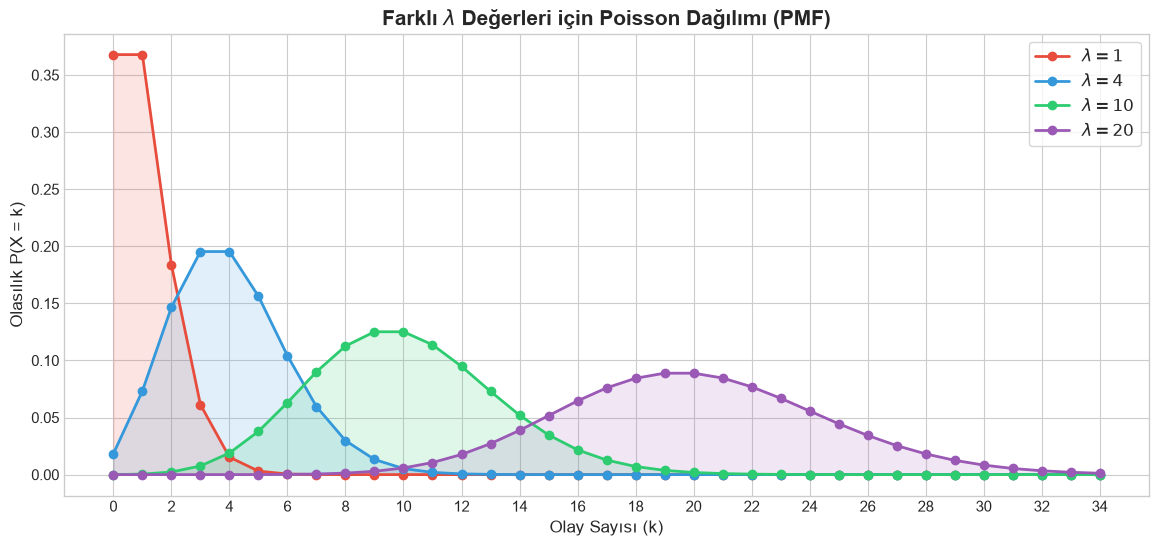

In [9]:
lambda_values = [1, 4, 10, 20]
k_range = np.arange(0, 35)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plt.figure(figsize=(14, 6))

for lam, color in zip(lambda_values, colors):
    pmf_vals = poisson.pmf(k_range, mu=lam)
    plt.plot(k_range, pmf_vals, marker='o', linewidth=2, color=color, label=f'$\lambda = {lam}$')
    plt.fill_between(k_range, 0, pmf_vals, color=color, alpha=0.15)

plt.title('Farklı $\lambda$ Değerleri için Poisson Dağılımı (PMF)', fontsize=15, fontweight='bold')
plt.xlabel('Olay Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık P(X = k)', fontsize=12)
plt.xticks(np.arange(0, 35, 2))
plt.legend(frameon=True, fontsize=12)
plt.show()

### 🎨 Grafik 2: Poisson Dağılımının Binom Dağılımına Yakınsaması (Nadir Olaylar Kuralı)

$n$ çok büyük ve $p$ çok küçükken ($n \cdot p = \lambda$ sabit), $\text{Binomial}(n, p) \approx \text{Poisson}(\lambda)$ olur.

<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/4139128450.py:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.bar(k_vals + width/2, poisson_probs, width=width, color='#e74c3c', alpha=0.85, label=f'Poisson($\lambda = {lam_approx}$)', edgecolor='black')
/var/f

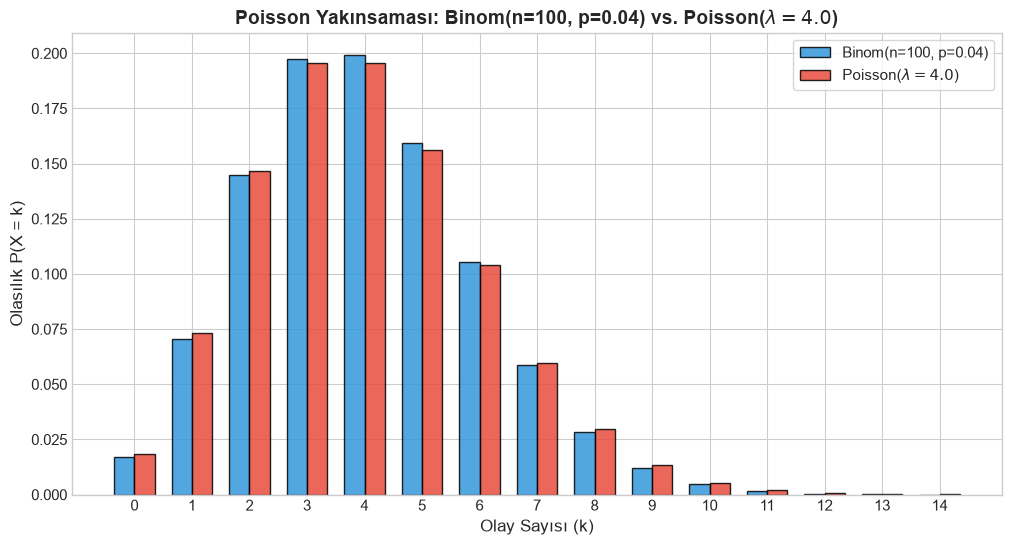

In [10]:
n_binom = 100
p_binom = 0.04
lam_approx = n_binom * p_binom  # lambda = 4

k_vals = np.arange(0, 15)
binom_probs = binom.pmf(k_vals, n=n_binom, p=p_binom)
poisson_probs = poisson.pmf(k_vals, mu=lam_approx)

plt.figure(figsize=(12, 6))
width = 0.35

plt.bar(k_vals - width/2, binom_probs, width=width, color='#3498db', alpha=0.85, label=f'Binom(n={n_binom}, p={p_binom})', edgecolor='black')
plt.bar(k_vals + width/2, poisson_probs, width=width, color='#e74c3c', alpha=0.85, label=f'Poisson($\lambda = {lam_approx}$)', edgecolor='black')

plt.title(f'Poisson Yakınsaması: Binom(n={n_binom}, p={p_binom}) vs. Poisson($\lambda={lam_approx}$)', fontsize=14, fontweight='bold')
plt.xlabel('Olay Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık P(X = k)', fontsize=12)
plt.xticks(k_vals)
plt.legend(frameon=True, fontsize=11)
plt.show()

### 🎨 Grafik 3: PMF vs. Kümülatif Dağılım Fonksiyonu (CDF)

<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/371589373.py:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.title(f'Poisson($\lambda = {lam_demo}$) Dağılımında PMF ve CDF Birlikte Gösterimi', fontsize=14, fontweight='bold')


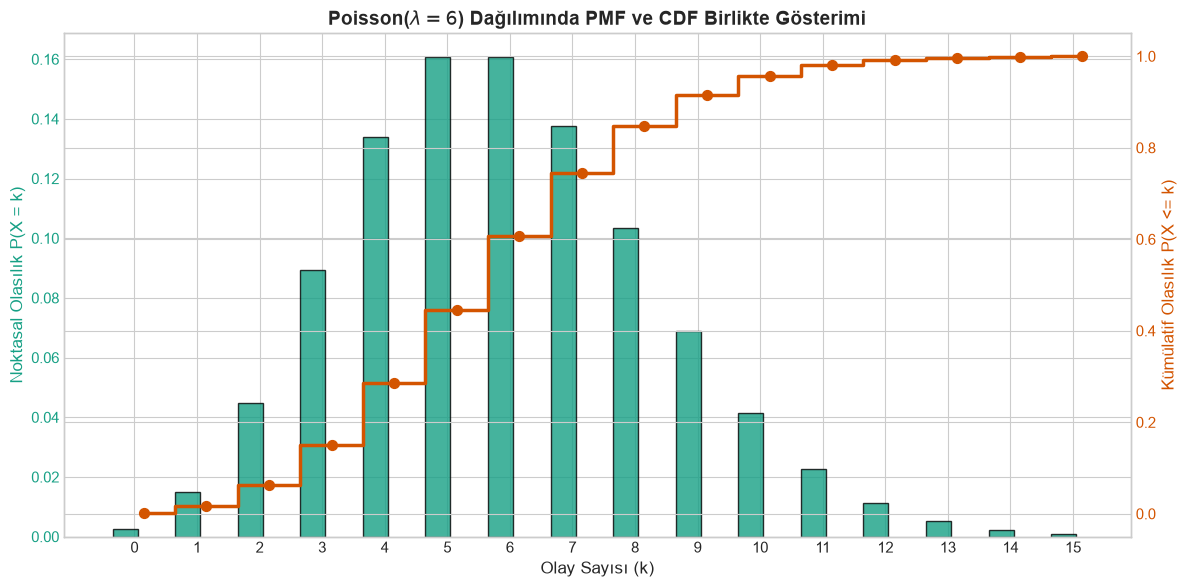

In [11]:
lam_demo = 6
k_arr = np.arange(0, 16)
pmf_demo = poisson.pmf(k_arr, mu=lam_demo)
cdf_demo = poisson.cdf(k_arr, mu=lam_demo)

fig, ax1 = plt.subplots(figsize=(12, 6))

# PMF Çubukları
ax1.bar(k_arr - 0.15, pmf_demo, width=0.4, color='#16a085', alpha=0.8, edgecolor='black', label='PMF: P(X = k)')
ax1.set_xlabel('Olay Sayısı (k)', fontsize=12)
ax1.set_ylabel('Noktasal Olasılık P(X = k)', color='#16a085', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#16a085')
ax1.set_xticks(k_arr)

# CDF Basamak Grafiği
ax2 = ax1.twinx()
ax2.step(k_arr + 0.15, cdf_demo, where='mid', color='#d35400', linewidth=2.5, label='CDF: P(X <= k)')
ax2.scatter(k_arr + 0.15, cdf_demo, color='#d35400', s=50, zorder=5)
ax2.set_ylabel('Kümülatif Olasılık P(X <= k)', color='#d35400', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d35400')
ax2.set_ylim(-0.05, 1.05)

plt.title(f'Poisson($\lambda = {lam_demo}$) Dağılımında PMF ve CDF Birlikte Gösterimi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 🔗 8. Poisson ile Diğer Dağılımların Karşılaştırması

| Karşılaştırma Kriteri | Binom Dağılımı | Poisson Dağılımı |
| :--- | :--- | :--- |
| **Olay Sayısı Üst Sınırı** | Sabit $n$ deneme ile sınırlı ($0 \le k \le n$) | Teorik olarak üst sınır yok ($k \in \{0, 1, 2, \dots\}$) |
| **Parametreler** | $n$ (deneme sayısı) ve $p$ (olasılık) | $\lambda$ (birim aralıktaki ortalama oran) |
| **Ortalama ($E[X]$)** | $n \cdot p$ | $\lambda$ |
| **Varyans ($\text{Var}[X]$)**| $n \cdot p \cdot (1 - p)$ ($< E[X]$) | $\lambda$ ($= E[X]$) |
| **Kullanım Alanı** | Başarı/başarısızlık sayısı bilinen durumlar | Sürekli zamanda/alanda nadir olay sıklığı |

---
## 📝 9. Özet ve Hızlı Başvuru Kartı

| Özellik | Formül / Açıklama |
| :--- | :--- |
| **Dağılım Türü** | Ayrık (Discrete) |
| **Parametre** | $\lambda > 0$ (Ortalama Gerçekleşme Oranı) |
| **Tanım Kümesi** | $k \in \{0, 1, 2, 3, \dots\}$ |
| **PMF** | $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$ |
| **Beklenen Değer** | $E[X] = \lambda$ |
| **Varyans** | $\text{Var}(X) = \lambda$ |
| **Standart Sapma** | $\sigma = \sqrt{\lambda}$ |
| **Python SciPy** | `scipy.stats.poisson(mu=lambda)` |
| **Python NumPy** | `np.random.poisson(lam=lambda, size=N)` |

---

---
# 📚 POISSON DAĞILIMI (POISSON DISTRIBUTION) - DETAYLI TEORİ VE UYGULAMA REHBERİ
### Olasılık Dağılımları Serisi - 03

---

## 📌 1. Giriş ve Sezgisel Anlatım

**Poisson Dağılımı**, belirli ve sabit bir zaman aralığında, alanda, hacimde veya uzunlukta meydana gelen olayların sayısını modelleyen **ayrık (discrete) bir olasılık dağılımıdır**.

Fransız matematikçi **Siméon Denis Poisson (1781–1840)** tarafından 1837 yılında geliştirilmiştir.

### 🔍 Bir Sürecin Poisson Dağılımına Uyması İçin 3 Temel Koşul:
1. **Bağımsızlık (Independence):** Bir zaman aralığında meydana gelen olay sayısı, diğer ayrık zaman aralıklarında meydana gelen olay sayısından bağımsızdır.
2. **Sabit Oran (Constant Rate - $\lambda$):** Birim zaman/alan başına ortalama gerçekleşme oranı ($\lambda$) süreç boyunca sabit kalmalıdır.
3. **Eşzamanlılık Olamaması (Non-Simultaneity):** Yeterince küçük bir zaman aralığında ($\Delta t \to 0$), aynı anda iki veya daha fazla olayın gerçekleşme olasılığı sıfıra yaklaşır.

### 🌍 Günlük Hayattan Örnekler:
- 📞 **Çağrı Merkezi:** 1 saatte müşteri hizmetlerine gelen çağrı sayısı.
- 🚦 **Trafik Akışı:** Belirli bir kavşaktan dakikada geçen araç sayısı.
- 🌐 **Sunucu Trafiği (Web Requests):** Bir web sunucusuna saniyede gelen HTTP istek sayısı.
- 🏥 **Sağlık & Tıp:** Bir hastanenin acil servisine gece saatlerinde gelen hasta sayısı.
- 🖨️ **Baskı & Üretim:** Bir kumaş topunda metre başına düşen dokuma hatası sayısı.

---
## 📐 2. Matematiksel Tanım ve Olasılık Kütle Fonksiyonu (PMF)

Bir rastgele değişken $X$, ortalama $\lambda$ (lambda) gerçekleşme hızı ile Poisson dağılımına sahipse şu şekilde gösterilir:

$$X \sim \text{Poisson}(\lambda)$$

Burada:
- $\lambda > 0$: Birim zaman/alan başına beklenen ortalama olay sayısı (Oran parametresi / Rate parameter)
- $k \in \{0, 1, 2, 3, \dots\}$: İncelenen zaman diliminde gerçekleşen olay sayısı ($k \in \mathbb{N}_0$)
- $e \approx 2.71828$: Euler sayısı (Doğal logaritma tabanı)

### 🔹 Olasılık Kütle Fonksiyonu (Probability Mass Function - PMF)
Belirli bir aralıkta tam olarak $k$ adet olayın gerçekleşme olasılığı:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

### 🔹 Kümülatif Dağılım Fonksiyonu (Cumulative Distribution Function - CDF)
Belirli bir aralıkta en fazla $k$ adet olayın gerçekleşme olasılığı:

$$F(k) = P(X \le k) = \sum_{i=0}^k \frac{\lambda^i e^{-\lambda}}{i!}$$

---

## 📊 3. İstatistiksel Özellikler ve Eşitlik İlkesi (Equidisperson)

> 💡 **Poisson Dağılımının En Önemli Özelliği:** Beklenen Değeri ile Varyansı birbirine tam olarak eşittir ($E[X] = \text{Var}(X) = \lambda$).

| İstatistiksel Metrik | Formül | Açıklama |
| :--- | :--- | :--- |
| **Beklenen Değer (Mean / $E[X]$)** | $\mu = \lambda$ | Birim aralıkta ortalama gerçekleşme sayısıdır. |
| **Varyans (Variance / $\text{Var}(X)$)** | $\sigma^2 = \lambda$ | Dağılımdaki değişkenlik ortalamaya eşittir. |
| **Standart Sapma (Standard Deviation)** | $\sigma = \sqrt{\lambda}$ | Varyansın kareköküdür. |
| **Çarpıklık (Skewness / $\gamma_1$)** | $\gamma_1 = \frac{1}{\sqrt{\lambda}}$ | $\lambda$ büyüdükçe $\gamma_1 \to 0$ olur ve dağılım simetrikleşir. |
| **Basıklık (Kurtosis Excess)** | $\text{Kurt} = \frac{1}{\lambda}$ | $\lambda$ büyüdükçe Normal dağılım basıklığına yaklaşır. |
| **Mod (Mode)** | $\lfloor \lambda \rfloor$ | En yüksek olasılığa sahip olay sayısıdır. |

---
## 💻 4. Python ile Kütüphaneleri Yükleme ve Ortam Ayarları

In [12]:
# Gerekli kütüphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, binom
from IPython.display import display

# Grafik estetiği ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Rastgelelik tohumu
np.random.seed(42)

print("✅ Poisson Dağılımı analiz ortamı hazırlandı!")

✅ Poisson Dağılımı analiz ortamı hazırlandı!


---
## 🎯 5. Gerçek Hayat Problemleri ve Adım Adım Çözümler

Notebook'un başında ele alınan örnekleri analitik olarak çözelim:

### 🅿️ Problem 1: Otopark Araç Giriş Modeli ($\lambda = 5$ araç/saat)
Bir otoparka saatte ortalama 5 araç girmektedir. Bir saatte:
1. Tam 5 araç gelme olasılığı $P(X = 5)$
2. En fazla 3 araç gelme olasılığı $P(X \le 3)$
3. 8'den fazla araç gelme (yoğunluk) olasılığı $P(X > 8)$

In [13]:
lam1 = 5  # Saatte ortalama 5 araç

prob_exact_5 = poisson.pmf(k=5, mu=lam1)   # P(X = 5)
prob_max_3 = poisson.cdf(k=3, mu=lam1)     # P(X <= 3)
prob_more_8 = poisson.sf(k=8, mu=lam1)     # P(X > 8) = 1 - P(X <= 8)

print(f"🅿️ Otopark Modeli (lambda = {lam1} araç/saat):")
print("-" * 45)
print(f"1. Tam 5 Araç Gelme Olasılığı P(X = 5)    : %{prob_exact_5 * 100:.2f} ({prob_exact_5:.4f})")
print(f"2. En Fazla 3 Araç Gelme Olasılığı P(X <= 3): %{prob_max_3 * 100:.2f} ({prob_max_3:.4f})")
print(f"3. 8'den Fazla Araç Gelme Olasılığı P(X > 8) : %{prob_more_8 * 100:.2f} ({prob_more_8:.4f})")

🅿️ Otopark Modeli (lambda = 5 araç/saat):
---------------------------------------------
1. Tam 5 Araç Gelme Olasılığı P(X = 5)    : %17.55 (0.1755)
2. En Fazla 3 Araç Gelme Olasılığı P(X <= 3): %26.50 (0.2650)
3. 8'den Fazla Araç Gelme Olasılığı P(X > 8) : %6.81 (0.0681)


### 📞 Problem 2: Çağrı Merkezi Modeli ($\lambda = 60$ çağrı/saat)
Bir çağrı merkezine saatte ortalama 60 çağrı gelmektedir:
- **Dakika bazında oran:** $\lambda_{dakika} = \frac{60}{60} = 1$ çağrı/dakika.
- **Soru:** Herhangi bir 1 dakikalık sürede hiç çağrı gelmeme ($k=0$) ve tam 2 çağrı gelme ($k=2$) olasılıkları nedir?

In [14]:
lam_min = 60 / 60  # lambda = 1 çağrı/dakika

prob_no_call = poisson.pmf(k=0, mu=lam_min)   # P(X = 0)
prob_2_calls = poisson.pmf(k=2, mu=lam_min)   # P(X = 2)
prob_at_least_1 = poisson.sf(k=0, mu=lam_min) # P(X >= 1)

print(f"📞 Çağrı Merkezi Modeli (Dakika Başına lambda = {lam_min:.1f}):")
print("-" * 45)
print(f"1. 1 Dakikada Hiç Çağrı Gelmeme Olasılığı P(X = 0)  : %{prob_no_call * 100:.2f} ({prob_no_call:.4f})")
print(f"2. 1 Dakikada Tam 2 Çağrı Gelme Olasılığı P(X = 2)  : %{prob_2_calls * 100:.2f} ({prob_2_calls:.4f})")
print(f"3. 1 Dakikada En Az 1 Çağrı Gelme Olasılığı P(X >= 1): %{prob_at_least_1 * 100:.2f} ({prob_at_least_1:.4f})")

📞 Çağrı Merkezi Modeli (Dakika Başına lambda = 1.0):
---------------------------------------------
1. 1 Dakikada Hiç Çağrı Gelmeme Olasılığı P(X = 0)  : %36.79 (0.3679)
2. 1 Dakikada Tam 2 Çağrı Gelme Olasılığı P(X = 2)  : %18.39 (0.1839)
3. 1 Dakikada En Az 1 Çağrı Gelme Olasılığı P(X >= 1): %63.21 (0.6321)


---
## 🔬 6. SciPy ile Poisson Dağılım Fonksiyonları

`scipy.stats.poisson` sınıfının sağladığı fonksiyonlar:
- `poisson.pmf(k, mu)`: $P(X = k)$
- `poisson.cdf(k, mu)`: $P(X \le k)$
- `poisson.sf(k, mu)`: $P(X > k)$
- `poisson.ppf(q, mu)`: Ters CDF (Quantile)
- `poisson.rvs(mu, size=N)`: Rastgele Poisson verisi üretimi
- `poisson.stats(mu, moments='mvsk')`: Ortalama, varyans, çarpıklık ve basıklık hesabı

In [15]:
mu_param = 8.5
mean, var, skew, kurt = poisson.stats(mu=mu_param, moments='mvsk')

print(f"🔹 Poisson(lambda = {mu_param}) Moment Analizi:")
print("-" * 45)
print(f"📊 Ortalama (E[X])       : {mean:.2f} (Beklenen: {mu_param})")
print(f"📐 Varyans (Var[X])     : {var:.2f} (Beklenen: {mu_param})")
print(f"📏 Standart Sapma       : {np.sqrt(var):.4f}")
print(f"📐 Çarpıklık (Skewness) : {skew:.4f} (1/sqrt(lambda) = {1/np.sqrt(mu_param):.4f})")
print(f"📊 Basıklık (Kurtosis)  : {kurt:.4f} (1/lambda = {1/mu_param:.4f})")

🔹 Poisson(lambda = 8.5) Moment Analizi:
---------------------------------------------
📊 Ortalama (E[X])       : 8.50 (Beklenen: 8.5)
📐 Varyans (Var[X])     : 8.50 (Beklenen: 8.5)
📏 Standart Sapma       : 2.9155
📐 Çarpıklık (Skewness) : 0.3430 (1/sqrt(lambda) = 0.3430)
📊 Basıklık (Kurtosis)  : 0.1176 (1/lambda = 0.1176)


---
## 📈 7. Kapsamlı Görselleştirmeler

### 🎨 Grafik 1: Farklı Oran ($\lambda$) Parametrelerinin PMF Üzerindeki Etkisi

<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/1081306504.py:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.plot(k_range, pmf_vals, marker='o', linewidth=2, color=color, label=f'$\lambda = {lam}$')
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97

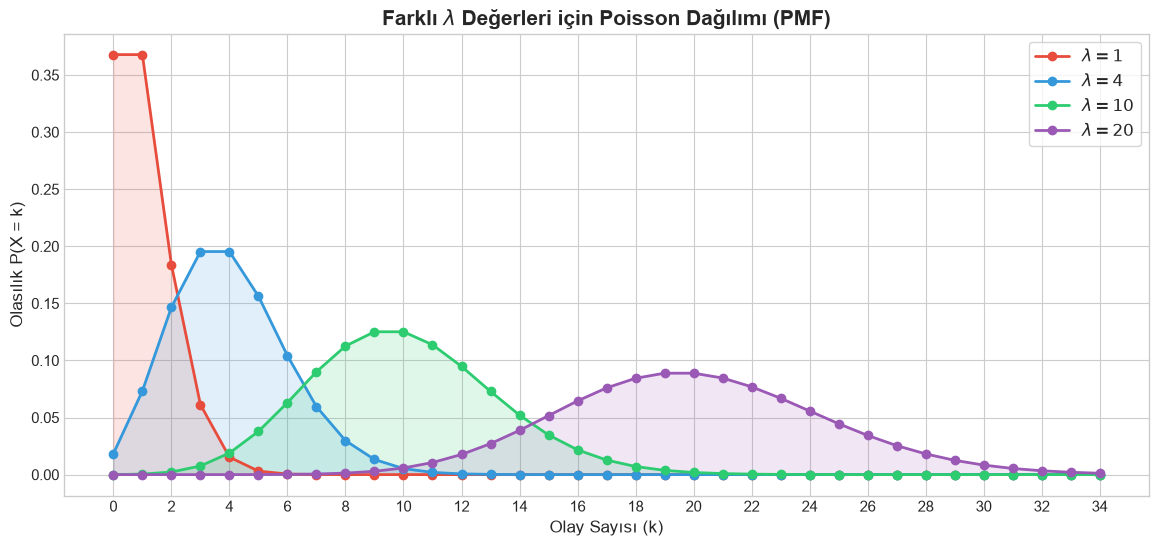

In [16]:
lambda_values = [1, 4, 10, 20]
k_range = np.arange(0, 35)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plt.figure(figsize=(14, 6))

for lam, color in zip(lambda_values, colors):
    pmf_vals = poisson.pmf(k_range, mu=lam)
    plt.plot(k_range, pmf_vals, marker='o', linewidth=2, color=color, label=f'$\lambda = {lam}$')
    plt.fill_between(k_range, 0, pmf_vals, color=color, alpha=0.15)

plt.title('Farklı $\lambda$ Değerleri için Poisson Dağılımı (PMF)', fontsize=15, fontweight='bold')
plt.xlabel('Olay Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık P(X = k)', fontsize=12)
plt.xticks(np.arange(0, 35, 2))
plt.legend(frameon=True, fontsize=12)
plt.show()

### 🎨 Grafik 2: Poisson Dağılımının Binom Dağılımına Yakınsaması (Nadir Olaylar Kuralı)

$n$ çok büyük ve $p$ çok küçükken ($n \cdot p = \lambda$ sabit), $\text{Binomial}(n, p) \approx \text{Poisson}(\lambda)$ olur.

<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:15: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/4139128450.py:13: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.bar(k_vals + width/2, poisson_probs, width=width, color='#e74c3c', alpha=0.85, label=f'Poisson($\lambda = {lam_approx}$)', edgecolor='black')
/var/f

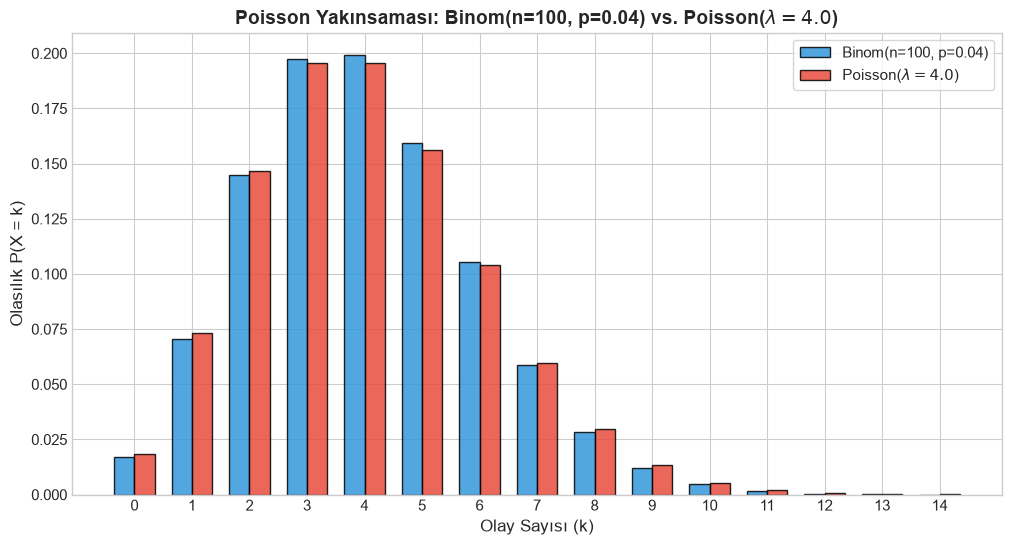

In [17]:
n_binom = 100
p_binom = 0.04
lam_approx = n_binom * p_binom  # lambda = 4

k_vals = np.arange(0, 15)
binom_probs = binom.pmf(k_vals, n=n_binom, p=p_binom)
poisson_probs = poisson.pmf(k_vals, mu=lam_approx)

plt.figure(figsize=(12, 6))
width = 0.35

plt.bar(k_vals - width/2, binom_probs, width=width, color='#3498db', alpha=0.85, label=f'Binom(n={n_binom}, p={p_binom})', edgecolor='black')
plt.bar(k_vals + width/2, poisson_probs, width=width, color='#e74c3c', alpha=0.85, label=f'Poisson($\lambda = {lam_approx}$)', edgecolor='black')

plt.title(f'Poisson Yakınsaması: Binom(n={n_binom}, p={p_binom}) vs. Poisson($\lambda={lam_approx}$)', fontsize=14, fontweight='bold')
plt.xlabel('Olay Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık P(X = k)', fontsize=12)
plt.xticks(k_vals)
plt.legend(frameon=True, fontsize=11)
plt.show()

### 🎨 Grafik 3: PMF vs. Kümülatif Dağılım Fonksiyonu (CDF)

<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97271/371589373.py:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.title(f'Poisson($\lambda = {lam_demo}$) Dağılımında PMF ve CDF Birlikte Gösterimi', fontsize=14, fontweight='bold')


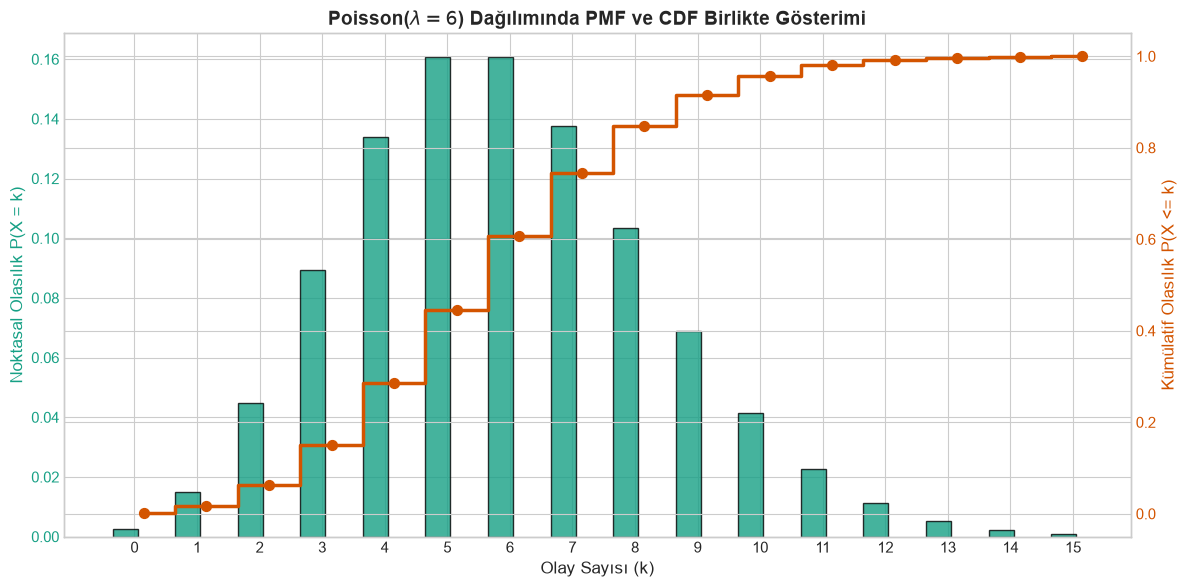

In [18]:
lam_demo = 6
k_arr = np.arange(0, 16)
pmf_demo = poisson.pmf(k_arr, mu=lam_demo)
cdf_demo = poisson.cdf(k_arr, mu=lam_demo)

fig, ax1 = plt.subplots(figsize=(12, 6))

# PMF Çubukları
ax1.bar(k_arr - 0.15, pmf_demo, width=0.4, color='#16a085', alpha=0.8, edgecolor='black', label='PMF: P(X = k)')
ax1.set_xlabel('Olay Sayısı (k)', fontsize=12)
ax1.set_ylabel('Noktasal Olasılık P(X = k)', color='#16a085', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#16a085')
ax1.set_xticks(k_arr)

# CDF Basamak Grafiği
ax2 = ax1.twinx()
ax2.step(k_arr + 0.15, cdf_demo, where='mid', color='#d35400', linewidth=2.5, label='CDF: P(X <= k)')
ax2.scatter(k_arr + 0.15, cdf_demo, color='#d35400', s=50, zorder=5)
ax2.set_ylabel('Kümülatif Olasılık P(X <= k)', color='#d35400', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d35400')
ax2.set_ylim(-0.05, 1.05)

plt.title(f'Poisson($\lambda = {lam_demo}$) Dağılımında PMF ve CDF Birlikte Gösterimi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 🔗 8. Poisson ile Diğer Dağılımların Karşılaştırması

| Karşılaştırma Kriteri | Binom Dağılımı | Poisson Dağılımı |
| :--- | :--- | :--- |
| **Olay Sayısı Üst Sınırı** | Sabit $n$ deneme ile sınırlı ($0 \le k \le n$) | Teorik olarak üst sınır yok ($k \in \{0, 1, 2, \dots\}$) |
| **Parametreler** | $n$ (deneme sayısı) ve $p$ (olasılık) | $\lambda$ (birim aralıktaki ortalama oran) |
| **Ortalama ($E[X]$)** | $n \cdot p$ | $\lambda$ |
| **Varyans ($\text{Var}[X]$)**| $n \cdot p \cdot (1 - p)$ ($< E[X]$) | $\lambda$ ($= E[X]$) |
| **Kullanım Alanı** | Başarı/başarısızlık sayısı bilinen durumlar | Sürekli zamanda/alanda nadir olay sıklığı |

---
## 📝 9. Özet ve Hızlı Başvuru Kartı

| Özellik | Formül / Açıklama |
| :--- | :--- |
| **Dağılım Türü** | Ayrık (Discrete) |
| **Parametre** | $\lambda > 0$ (Ortalama Gerçekleşme Oranı) |
| **Tanım Kümesi** | $k \in \{0, 1, 2, 3, \dots\}$ |
| **PMF** | $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$ |
| **Beklenen Değer** | $E[X] = \lambda$ |
| **Varyans** | $\text{Var}(X) = \lambda$ |
| **Standart Sapma** | $\sigma = \sqrt{\lambda}$ |
| **Python SciPy** | `scipy.stats.poisson(mu=lambda)` |
| **Python NumPy** | `np.random.poisson(lam=lambda, size=N)` |

---